# AMS for historical drought

Trend slope: -0.017 AMS units per year


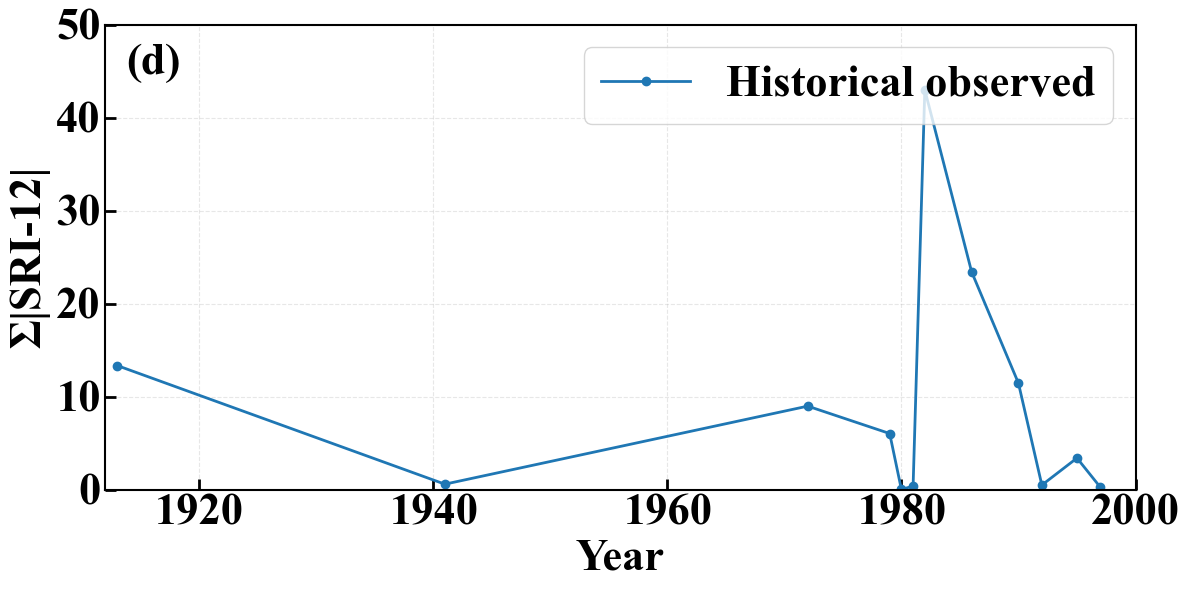

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================================
# 0) Global style (bold, Nature-like)
# ==========================================================
mpl.rcParams["font.family"]    = "serif"
mpl.rcParams["font.serif"]     = ["Times New Roman", "Times", "DejaVu Serif"]

mpl.rcParams["axes.labelsize"] = 18
mpl.rcParams["axes.titlesize"] = 20

# BIGGER NUMBERS ON AXES
mpl.rcParams["xtick.labelsize"] = 25   # x-axis numbers
mpl.rcParams["ytick.labelsize"] = 25   # y-axis numbers

mpl.rcParams["legend.fontsize"] = 18



# ==========================================================
# 1) Load SRI-12 (Dongola)
# ==========================================================
sri_path = r"\historical observed datat\Dongola_SRI12_gamma.xlsx"       # CHANGE THIS TO YOUR PATH
df_sri = pd.read_excel(sri_path, sheet_name=0)

# detect date + SRI columns
date_col = None
for c in df_sri.columns:
    if str(c).strip().lower() in ["date", "time", "datetime"]:
        date_col = c
        break
if date_col is None:
    date_col = df_sri.columns[0]

sri_col = None
for c in df_sri.columns:
    cl = str(c).strip().lower()
    if "sri12" in cl or cl == "sri" or "sri" in cl:
        sri_col = c
        break
if sri_col is None:
    raise ValueError(f"Could not detect SRI column in {df_sri.columns.tolist()}.")

df_sri[date_col] = pd.to_datetime(df_sri[date_col])
df_sri = df_sri.sort_values(date_col)

series = df_sri.set_index(date_col)[sri_col].astype(float)

# ==========================================================
# 2) Drought events + severity (threshold-run)
# ==========================================================
threshold = -1.0
events = []
in_drought = False
start = None

for date, val in series.items():
    if val <= threshold:
        if not in_drought:
            in_drought = True
            start = date
    else:
        if in_drought:
            end = date
            events.append({"Start": start, "End": end})
            in_drought = False

if in_drought:
    events.append({"Start": start, "End": series.index[-1]})

drought_df = pd.DataFrame(events)

if not drought_df.empty:
    durations = []
    severities = []
    min_sri_vals = []
    years_start = []

    for _, row in drought_df.iterrows():
        mask = (series.index >= row["Start"]) & (series.index <= row["End"])
        event_vals = series.loc[mask]
        event_vals = event_vals[event_vals <= threshold]

        dur_months = len(event_vals)
        sev = float((threshold - event_vals).sum())
        min_sri = float(event_vals.min())

        durations.append(dur_months)
        severities.append(sev)
        min_sri_vals.append(min_sri)
        years_start.append(row["Start"].year)

    drought_df["Duration_months"] = durations
    drought_df["Severity"] = severities
    drought_df["Min_SRI"] = min_sri_vals
    drought_df["Year_start"] = years_start
else:
    drought_df["Duration_months"] = []
    drought_df["Severity"] = []
    drought_df["Min_SRI"] = []
    drought_df["Year_start"] = []

# ==========================================================
# 3) Annual maximum severity (AMS) per year
# ==========================================================
if not drought_df.empty:
    tmp = drought_df.sort_values(
        ["Year_start", "Severity", "Duration_months"],
        ascending=[True, False, False]
    )
    best = tmp.drop_duplicates(subset=["Year_start"], keep="first").copy()

    ams = best[["Year_start", "Severity", "Duration_months"]].copy()
    ams = ams.rename(columns={
        "Year_start": "Year",
        "Severity": "AMS_max_severity",
        "Duration_months": "Duration_months_of_max",
    })
else:
    ams = pd.DataFrame(columns=["Year", "AMS_max_severity", "Duration_months_of_max"])

# ==========================================================
# 4) Subset 1912–2000 and fit linear trend
# ==========================================================
mask = (ams["Year"] >= 1912) & (ams["Year"] <= 2000)
sub = ams.loc[mask].sort_values("Year").copy()

x = sub["Year"].values.astype(float)
y = sub["AMS_max_severity"].values.astype(float)

# linear trend y = a*x + b
a, b = np.polyfit(x, y, 1)
y_trend = a * x + b
print(f"Trend slope: {a:.3f} AMS units per year")

# ==========================================================
# 5) Plot AMS (1912–2000) + trend (panel c style)
mpl.rcParams["font.weight"] = "bold"
mpl.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.unicode_minus"] = True
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x, y, "-o", color="#1f77b4", linewidth=2, markersize=6,
        label="Historical observed")
ax.set_xlabel("Year", fontsize=32)
ax.set_ylabel("Σ|SRI-12|", fontsize=32, fontweight="bold")
ax.set_ylim(0, 50)
ax.set_xlim(1912, 2000)

ax.tick_params(axis="both", which="major", labelsize=32
               , width=2)
ax.tick_params(axis="both", direction='in' , length=8, width=2)
# make tick numbers bold
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

ax.grid(True, linestyle="--", alpha=0.3)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

ax.legend(loc="upper right", fontsize=32)
# panel label
ax.text(0.02, 0.96, "(d)", transform=ax.transAxes,
        fontsize=32, fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.show()

# AMS for the future hydrological drought

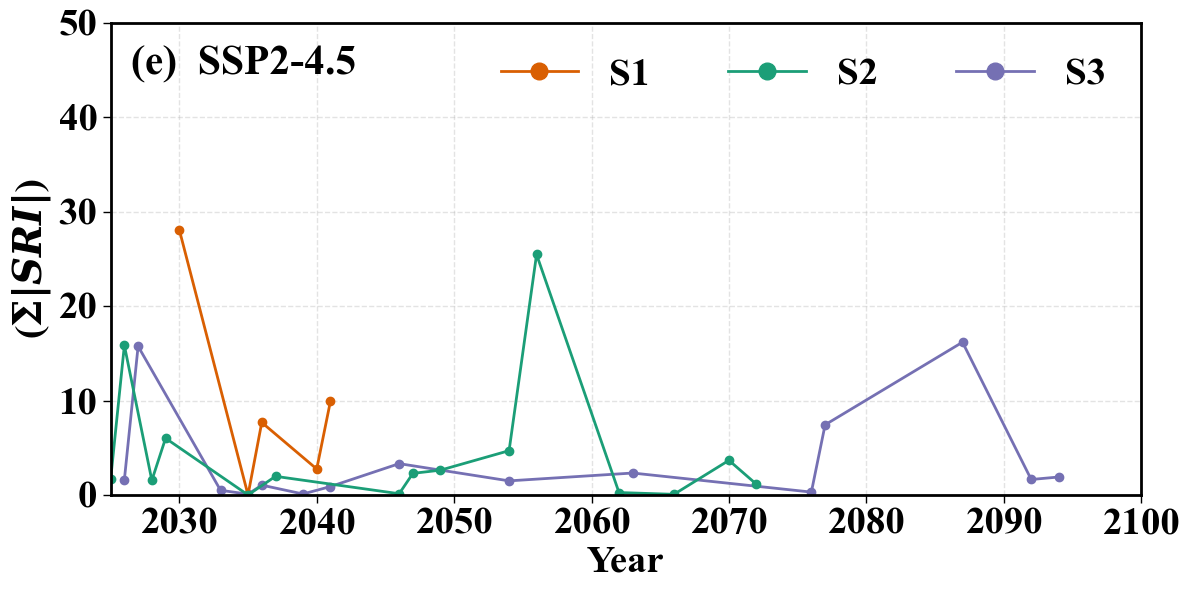

Saved: D:\doaa drought paper_revision\future stream flow\AMS_outputs\plots\AMS_SSP2-4.5.png


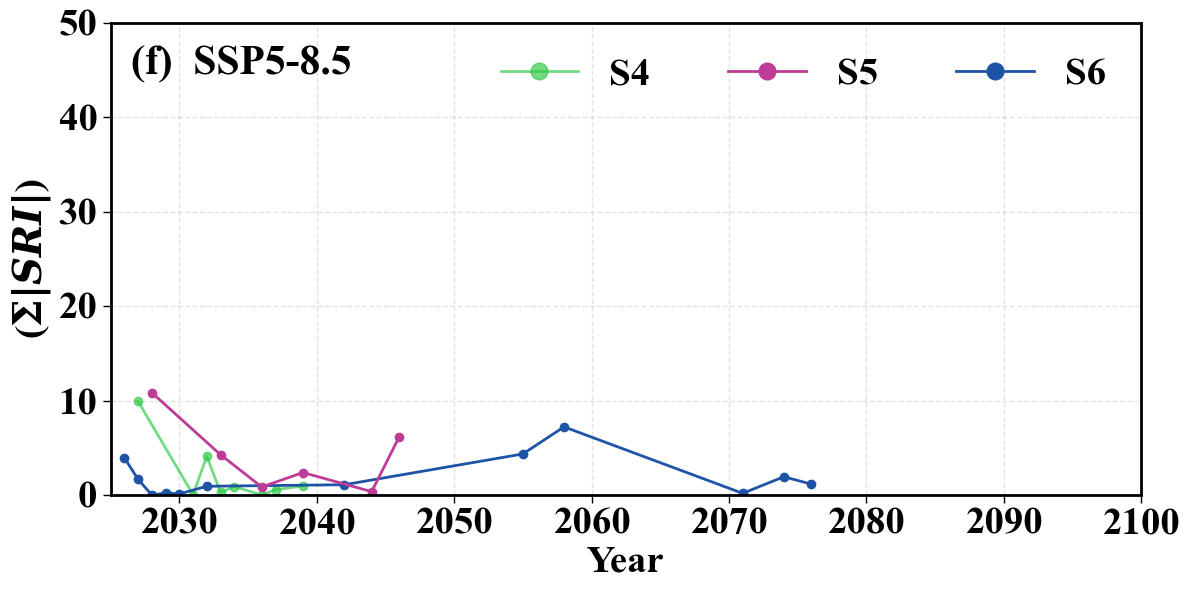

Saved: D:\doaa drought paper_revision\future stream flow\AMS_outputs\plots\AMS_SSP5-8.5.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# INPUT / OUTPUT
# ------------------------------------------------------------
in_path = r"\future stream flow\future_AMS_all_models_gamma_FIXED.xlsx"           # CHANGE THIS TO YOUR PATH
out_dir = r"\future stream flow\AMS_outputs\plots"                                 # CHANGE THIS TO YOUR PATH
os.makedirs(out_dir, exist_ok=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------
YEAR_MIN, YEAR_MAX = 2025, 2100
Y_LABEL = r"($\Sigma |SRI|$)"

PANEL_LABELS = {"SSP2-4.5": "(e)", "SSP5-8.5": "(f)"}

MODEL_LABELS = {
    "CMCC-CM2-SR5": "S2",
    "CESM2-WACCM":  "S1",
    "BCC-CSM2-MR":  "S3",
    "CanESM5":      "S4",
    "NorESM2-LM":   "S5",
    "INM-CM4-8":    "S6",
}

MODEL_COLORS = {
    "CMCC-CM2-SR5": "#1b9e77",
    "CESM2-WACCM":  "#d95f02",
    "BCC-CSM2-MR":  "#7570b3",
    "CanESM5":      "#2fc949ac",
    "INM-CM4-8":    "#1e54a6",
    "NorESM2-LM":   "#be3b97",
}

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_excel(in_path)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["AMS"]  = pd.to_numeric(df["AMS"], errors="coerce")
df = df.dropna(subset=["year", "AMS", "model", "scenario"])
df["year"] = df["year"].astype(int)

df = df[(df["year"] >= YEAR_MIN) & (df["year"] <= YEAR_MAX)]
df = df[df["AMS"] > 0]

# ------------------------------------------------------------
# STYLE
# ------------------------------------------------------------
def style_axes(ax):
    ax.grid(True, linestyle="--", linewidth=1, alpha=0.35)
    ax.tick_params(axis="both", labelsize=28, width=1.0, length=6)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

def ordered_legend(ax, scen):
    handles, labels = ax.get_legend_handles_labels()

    if scen == "SSP2-4.5":
        order = ["S1", "S2", "S3"]
    else:
        order = ["S4", "S5", "S6"]

    mapping = {lab: h for h, lab in zip(handles, labels)}
    hs = [mapping[o] for o in order if o in mapping]
    ls = [o for o in order if o in mapping]

    leg = ax.legend(
        hs, ls,
        loc="upper right",
        ncol=3,
        fontsize=28,
        markerscale=2,
        frameon=False
    )

    for txt in leg.get_texts():
        txt.set_fontweight("bold")

# ------------------------------------------------------------
# PLOT SEPARATE FIGURES
# ------------------------------------------------------------
for scen in ["SSP2-4.5", "SSP5-8.5"]:

    fig, ax = plt.subplots(figsize=(12,6))

    d = df[df["scenario"] == scen]

    for model, g in d.groupby("model"):
        g = g.sort_values("year")

        ax.plot(
            g["year"], g["AMS"],
            color=MODEL_COLORS.get(model),
            linewidth=2,
            marker="o",
            markersize=6,
            label=MODEL_LABELS.get(model)
        )

    # combined label (e) SSP2-4.5
    ax.text(
        0.02, 0.95,
        f"{PANEL_LABELS[scen]}  {scen}",
        transform=ax.transAxes,
        fontsize=30,
        fontweight="bold",
        va="top"
    )

    ax.set_ylabel(Y_LABEL, fontsize=28, fontweight="bold")
    ax.set_xlabel("Year", fontsize=28, fontweight="bold")

    ax.set_xlim(2025, 2100)
    ax.set_ylim(0, 50)
    ax.set_xlim(2025, 2100)

    style_axes(ax)
    ordered_legend(ax, scen)

    plt.tight_layout()

    out_png = os.path.join(out_dir, f"AMS_{scen}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)